In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import random, json, time
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use("dark_background")
print(f"Device  : {device}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"PyTorch : {torch.__version__}")


Device  : cuda
GPU     : NVIDIA RTX A5000
PyTorch : 2.8.0+cu128


In [ ]:
#─ PATHS ────────────────────────────────────────────────────

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

TRAIN_DIR = DATA_DIR / "Training"
VAL_DIR   = DATA_DIR / "Validation"
MODEL_OUT_DIR = PROJECT_ROOT / "models"
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# ── HYPERPARAMETERS ─────────────────────────────────────────

HEIGHT     = 256
WIDTH      = 256
BATCH_SIZE = 32
EPOCHS     = 70
LR         = 1e-3
SNR_MIN    = -5
SNR_MAX    = 25
SEED       = 42

# Skip training; use existing checkpoints.
SKIP_TRAINING = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Config loaded ✅")
print("Device:", DEVICE)
print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)
print("Models dir:", MODEL_OUT_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Val exists:", VAL_DIR.exists())

Config loaded ✅
Device: cuda
Train exists: True
Val exists: True


In [ ]:
class PhaseDenoiseDataset(Dataset):
    def __init__(self, paths, img_size=(256,256), fix_noise=False, snr_min=-5, snr_max=25):
        self.paths    = paths
        self.img_size = img_size
        self.fix      = fix_noise
        self.snr_min  = snr_min
        self.snr_max  = snr_max

    def __len__(self): return len(self.paths)

    def add_noise_snr(self, clean, snr_db):
        """Paper eq(11): sigma^2 = E[Y^2] / 10^(SNR/10)"""
        sig_power = torch.mean(clean**2).item()
        sigma     = (sig_power / (10**(snr_db/10)))**0.5
        return (clean + torch.randn_like(clean)*sigma).clamp(0,1)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert("L").resize(self.img_size, Image.NEAREST)
        clean = torch.from_numpy(np.array(img, dtype=np.float32)/255.0).unsqueeze(0)

        if self.fix:
            random.seed(idx); np.random.seed(idx); torch.manual_seed(idx)

        snr   = random.uniform(self.snr_min, self.snr_max)
        noisy = self.add_noise_snr(clean, snr)
        return noisy, clean


# Collect + split 70/15/15
exts = {".jpg",".jpeg",".png"}
all_images = []
if not TRAIN_DIR.exists() or not VAL_DIR.exists():
    print("Training/Validation folders are missing. Create them and add images.")
else:
    all_images = (
        sorted(f for f in TRAIN_DIR.iterdir() if f.suffix.lower() in exts) +
        sorted(f for f in VAL_DIR.iterdir()   if f.suffix.lower() in exts)
    )

random.shuffle(all_images)
n          = len(all_images)

if n == 0:
    print("No images found in Training/Validation. Add images and rerun this cell.")
    train_p = []
    val_p = []
    test_p = []
    train_ds = None
    val_ds = None
    test_ds = None
    train_loader = None
    val_loader = None
    test_loader = None
else:
    train_p    = all_images[:int(0.70*n)]
    val_p      = all_images[int(0.70*n):int(0.85*n)]
    test_p     = all_images[int(0.85*n):]

    train_ds = PhaseDenoiseDataset(train_p, (HEIGHT,WIDTH), fix_noise=False)
    val_ds   = PhaseDenoiseDataset(val_p,   (HEIGHT,WIDTH), fix_noise=True)
    test_ds  = PhaseDenoiseDataset(test_p,  (HEIGHT,WIDTH), fix_noise=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"Total  : {n}")
    print(f"Train  : {len(train_p)} ({len(train_p)/n*100:.0f}%)")
    print(f"Val    : {len(val_p)}   ({len(val_p)/n*100:.0f}%)")
    print(f"Test   : {len(test_p)}  ({len(test_p)/n*100:.0f}%)")

Total  : 36864
Train  : 25804 (70%)
Val    : 5530   (15%)
Test   : 5530  (15%)


In [ ]:
import os

base = str(DATA_DIR)

if not Path(base).exists():
    print("Data folder not found:", base)
else:
    for root, dirs, files in os.walk(base):
        print(root)

/home/admincit/Desktop/phase/Training-20260312T053631Z-1-001
/home/admincit/Desktop/phase/Training-20260312T053631Z-1-001/Training
/home/admincit/Desktop/phase/Training-20260312T053631Z-1-001/Validation


In [35]:
class StandardCNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, use_bn=True):
        super().__init__()
        p = ks//2
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, ks, padding=p), nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, ks, padding=p), nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, ks, padding=p), nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class DilatedCNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, dilations=(1,2,4), use_bn=True):
        super().__init__()
        self.c1=nn.Conv2d(in_ch,  out_ch, ks, padding=dilations[0], dilation=dilations[0])
        self.c2=nn.Conv2d(out_ch, out_ch, ks, padding=dilations[1], dilation=dilations[1])
        self.c3=nn.Conv2d(out_ch, out_ch, ks, padding=dilations[2], dilation=dilations[2])
        self.b1=nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        self.b2=nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        self.b3=nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        self.relu=nn.ReLU(inplace=True)
    def forward(self, x):
        x=self.relu(self.b1(self.c1(x)))
        x=self.relu(self.b2(self.c2(x)))
        x=self.relu(self.b3(self.c3(x)))
        return x

class DepthwiseCNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, use_bn=True):
        super().__init__()
        p=ks//2
        def dw_pw(i,o):
            return nn.Sequential(
                nn.Conv2d(i,i,ks,padding=p,groups=i),
                nn.BatchNorm2d(i) if use_bn else nn.Identity(), nn.ReLU(inplace=True),
                nn.Conv2d(i,o,1),
                nn.BatchNorm2d(o) if use_bn else nn.Identity(), nn.ReLU(inplace=True),
            )
        self.b1=dw_pw(in_ch,out_ch)
        self.b2=dw_pw(out_ch,out_ch)
        self.b3=dw_pw(out_ch,out_ch)
    def forward(self, x): return self.b3(self.b2(self.b1(x)))

class MultiBranchModule(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, dilations=(1,2,4), use_bn=True):
        super().__init__()
        self.std=StandardCNNBlock(in_ch,out_ch,ks,use_bn)
        self.dil=DilatedCNNBlock(in_ch,out_ch,ks,dilations,use_bn)
        self.dw =DepthwiseCNNBlock(in_ch,out_ch,ks,use_bn)
        self.fuse=nn.Sequential(
            nn.Conv2d(out_ch*3,out_ch,1),
            nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.fuse(torch.cat([self.std(x),self.dil(x),self.dw(x)],dim=1))

class SEBlock(nn.Module):
    def __init__(self, ch, r=4):
        super().__init__()
        mid=max(1,ch//r)
        self.se=nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(ch,mid,1,bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(mid,ch,1,bias=False), nn.Sigmoid()
        )
    def forward(self, x): return x*self.se(x)

class MBConv(nn.Module):
    def __init__(self, in_ch, out_ch, expand=4, ks=3, use_se=True, use_bn=True):
        super().__init__()
        hid=in_ch*expand
        self.use_res=(in_ch==out_ch)
        layers=[
            nn.Conv2d(in_ch,hid,1,bias=False),
            nn.BatchNorm2d(hid) if use_bn else nn.Identity(), nn.SiLU(inplace=True),
            nn.Conv2d(hid,hid,ks,padding=ks//2,groups=hid,bias=False),
            nn.BatchNorm2d(hid) if use_bn else nn.Identity(), nn.SiLU(inplace=True),
        ]
        if use_se: layers.append(SEBlock(hid))
        layers+=[nn.Conv2d(hid,out_ch,1,bias=False),
                 nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()]
        self.conv=nn.Sequential(*layers)
    def forward(self, x):
        return x+self.conv(x) if self.use_res else self.conv(x)

class FusedMBConv(nn.Module):
    def __init__(self, in_ch, out_ch, expand=4, ks=3, use_bn=True):
        super().__init__()
        hid=in_ch*expand
        self.use_res=(in_ch==out_ch)
        self.conv=nn.Sequential(
            nn.Conv2d(in_ch,hid,ks,padding=ks//2,bias=False),
            nn.BatchNorm2d(hid) if use_bn else nn.Identity(), nn.SiLU(inplace=True),
            nn.Conv2d(hid,out_ch,1,bias=False),
            nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        )
    def forward(self, x):
        return x+self.conv(x) if self.use_res else self.conv(x)

class CBAM(nn.Module):
    def __init__(self, ch):
        super().__init__()
        mid=max(1,ch//2)
        self.ca=nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Conv2d(ch,mid,1,bias=False),
            nn.ReLU(inplace=True),  nn.Conv2d(mid,ch,1,bias=False), nn.Sigmoid()
        )
        self.sa=nn.Sequential(nn.Conv2d(2,1,7,padding=3,bias=False),nn.Sigmoid())
    def forward(self, x):
        x=x*self.ca(x)
        avg=torch.mean(x,dim=1,keepdim=True)
        mx,_=torch.max(x,dim=1,keepdim=True)
        return x*self.sa(torch.cat([avg,mx],dim=1))

class ReducedUNet(nn.Module):
    def __init__(self, in_ch, base=16, use_bn=True, use_cbam=True):
        super().__init__()
        f1,f2,f3,fb=base,base*2,base*4,base*8
        def blk(i,o): return nn.Sequential(
            nn.Conv2d(i,o,3,padding=1), nn.BatchNorm2d(o) if use_bn else nn.Identity(), nn.ReLU(inplace=True),
            nn.Conv2d(o,o,3,padding=1), nn.BatchNorm2d(o) if use_bn else nn.Identity(), nn.ReLU(inplace=True),
        )
        self.enc1,self.enc2,self.enc3=blk(in_ch,f1),blk(f1,f2),blk(f2,f3)
        self.pool=nn.MaxPool2d(2)
        self.bn_cnn =blk(f3,fb)
        self.bn_cbam=CBAM(f3) if use_cbam else nn.Identity()
        self.bn_fuse=nn.Conv2d(fb+f3,fb,1)
        self.up3,self.dec3=nn.ConvTranspose2d(fb,f3,2,2),blk(f3+f3,f3)
        self.up2,self.dec2=nn.ConvTranspose2d(f3,f2,2,2),blk(f2+f2,f2)
        self.up1,self.dec1=nn.ConvTranspose2d(f2,f1,2,2),blk(f1+f1,f1)
        self.out=nn.Conv2d(f1,in_ch,1) if f1!=in_ch else nn.Identity()
    def forward(self, x):
        e1=self.enc1(x);  p1=self.pool(e1)
        e2=self.enc2(p1); p2=self.pool(e2)
        e3=self.enc3(p2); p3=self.pool(e3)
        b=self.bn_fuse(torch.cat([self.bn_cnn(p3),self.bn_cbam(p3)],dim=1))
        d3=self.dec3(torch.cat([self.up3(b), e3],dim=1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],dim=1))
        d1=self.dec1(torch.cat([self.up1(d2),e1],dim=1))
        return self.out(d1)+x

class AdvancedDenoisingModel(nn.Module):
    def __init__(self, in_ch=1, s1=16, s2=32, unet_base=16, s4=16, use_bn=True, use_cbam=True):
        super().__init__()
        self.stage1=MultiBranchModule(in_ch, s1,  use_bn=use_bn)
        self.stage2=MBConv(in_ch+s1,       s2,   use_se=False, use_bn=use_bn)
        self.stage3=ReducedUNet(s2, base=unet_base, use_bn=use_bn, use_cbam=use_cbam)
        self.stage4=FusedMBConv(s2,        s4,   use_bn=use_bn)
        self.refine=MultiBranchModule(s4,  s4,   use_bn=use_bn)
        self.output=nn.Conv2d(s4, in_ch, 1)
    def forward(self, x):
        s1=self.stage1(x)
        s2=self.stage2(torch.cat([x,s1],dim=1))
        s3=self.stage3(s2)
        s4=self.refine(self.stage4(s3))
        return x + self.output(s4)   # ✅ global residual

model = AdvancedDenoisingModel(in_ch=1,s1=16,s2=32,unet_base=16,s4=16).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Output : {model(torch.randn(2,1,256,256).to(device)).shape}")
print(f"✅ Total params     : {total_params:,}")
print(f"✅ Trainable params : {trainable:,}")


✅ Output : torch.Size([2, 1, 256, 256])
✅ Total params     : 588,631
✅ Trainable params : 588,631


In [36]:
psnr_m = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_m = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# Charbonnier + SSIM loss (best for denoising papers)
def combined_loss(pred, target, eps=1e-6):
    charb = torch.mean(torch.sqrt((pred-target)**2 + eps**2))
    ssim  = 1 - ssim_m(pred.clamp(0,1), target)
    return 0.7*charb + 0.3*ssim

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9,0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print("Loss + Optimizer ready ✅")


Loss + Optimizer ready ✅


In [ ]:
def run_epoch(model, loader, optimizer=None, train=True):
    if loader is None or len(loader) == 0:
        raise ValueError("Data loader is empty. Add images to data/Training and data/Validation.")
    model.train() if train else model.eval()
    total_loss=0; psnr_m.reset(); ssim_m.reset()
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in tqdm(loader, desc="Train" if train else "Val  ", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = combined_loss(out, masks)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item()
            psnr_m.update(out.detach().clamp(0,1), masks)
            ssim_m.update(out.detach().clamp(0,1), masks)
    n = len(loader)
    return total_loss/n, psnr_m.compute().item(), ssim_m.compute().item()

In [38]:
import torch, gc

# Clear unused tensors
gc.collect()
torch.cuda.empty_cache()

# Verify freed memory
print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")
print(f"Free:      {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved())/1e9:.2f} GB")

Allocated: 0.58 GB
Reserved:  1.24 GB
Free:      24.18 GB


In [ ]:
history = {
    "train_loss":[], "val_loss":[],
    "train_psnr":[], "val_psnr":[],
    "train_ssim":[], "val_ssim":[],
    "lr":[]
}
best_val_psnr = 0.0
best_val_loss = float("inf")
start_time    = time.time()

if SKIP_TRAINING:
    best_path = MODEL_OUT_DIR / "best_model.pth"
    if best_path.exists():
        ckpt = torch.load(best_path, map_location=device)
        history = ckpt.get("history", history)
        best_val_psnr = ckpt.get("val_psnr", best_val_psnr)
        best_val_loss = ckpt.get("val_loss", best_val_loss)
        print("Skipping training. Loaded history from checkpoint.")
    else:
        print("Skipping training. No checkpoint found yet.")
else:
    print(f"Starting training — {EPOCHS} epochs\n{'='*55}")

    for epoch in range(EPOCHS):
        ep_start = time.time()

        tl,tp,ts = run_epoch(model, train_loader, optimizer, train=True)
        vl,vp,vs = run_epoch(model, val_loader,              train=False)
        scheduler.step()

        lr_now = scheduler.get_last_lr()[0]
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_psnr"].append(tp); history["val_psnr"].append(vp)
        history["train_ssim"].append(ts); history["val_ssim"].append(vs)
        history["lr"].append(lr_now)

        ep_time = time.time() - ep_start
        eta     = ep_time * (EPOCHS - epoch - 1)

        print(f"Ep {epoch+1:03d}/{EPOCHS} | "
              f"Train → Loss:{tl:.4f} PSNR:{tp:.2f}dB SSIM:{ts:.4f} | "
              f"Val → Loss:{vl:.4f} PSNR:{vp:.2f}dB SSIM:{vs:.4f} | "
              f"LR:{lr_now:.6f} | ETA:{eta/60:.1f}min")

        # Save best model
        if vp > best_val_psnr:
            best_val_psnr = vp
            best_val_loss = vl
            torch.save({
                "epoch"       : epoch+1,
                "model_state" : model.state_dict(),
                "optimizer"   : optimizer.state_dict(),
                "val_psnr"    : vp,
                "val_ssim"    : vs,
                "val_loss"    : vl,
                "history"     : history,
            }, MODEL_OUT_DIR/"best_model.pth")
            print(f"  Best saved! PSNR:{vp:.2f}dB")

    # Save final + history
    torch.save(model.state_dict(), MODEL_OUT_DIR/"final_model.pth")
    with open(MODEL_OUT_DIR/"history.json","w") as f:
        json.dump(history, f, indent=2)

    total_time = (time.time()-start_time)/60
    print(f"\n{'='*55}")
    print("Training done.")
    print(f"Best Val PSNR : {best_val_psnr:.2f} dB")
    if history["val_psnr"]:
        best_idx = history["val_psnr"].index(best_val_psnr)
        print(f"Best Val SSIM : {history['val_ssim'][best_idx]:.4f}")
    print(f"Total Time    : {total_time:.1f} min")

Starting training — 70 epochs


Ep 001/70 | Train → Loss:0.1258 PSNR:21.72dB SSIM:0.6879 | Val → Loss:0.0803 PSNR:24.27dB SSIM:0.8115 | LR:0.000999 | ETA:554.6min
  ✅ Best saved! PSNR:24.27dB


Ep 002/70 | Train → Loss:0.0768 PSNR:25.07dB SSIM:0.8151 | Val → Loss:0.0623 PSNR:25.81dB SSIM:0.8569 | LR:0.000998 | ETA:546.9min
  ✅ Best saved! PSNR:25.81dB


Ep 003/70 | Train → Loss:0.0610 PSNR:25.98dB SSIM:0.8592 | Val → Loss:0.0524 PSNR:25.42dB SSIM:0.8953 | LR:0.000995 | ETA:539.6min


Ep 004/70 | Train → Loss:0.0552 PSNR:26.46dB SSIM:0.8745 | Val → Loss:0.0466 PSNR:26.43dB SSIM:0.9039 | LR:0.000992 | ETA:530.2min
  ✅ Best saved! PSNR:26.43dB


...

Ep 066/70 | Train → Loss:0.0277 PSNR:29.06dB SSIM:0.9465 | Val → Loss:0.0293 PSNR:28.98dB SSIM:0.9415 | LR:0.000009 | ETA:29.9min


Ep 067/70 | Train → Loss:0.0278 PSNR:29.05dB SSIM:0.9462 | Val → Loss:0.0284 PSNR:29.00dB SSIM:0.9442 | LR:0.000006 | ETA:22.4min


Ep 068/70 | Train → Loss:0.0278 PSNR:29.03dB SSIM:0.9464 | Val → Loss:0.0289 PSNR:28.98dB SSIM:0.9427 | LR:0.000003 | ETA:15.0min


Ep 069/70 | Train → Loss:0.0277 PSNR:29.05dB SSIM:0.9465 | Val → Loss:0.0288 PSNR:28.99dB SSIM:0.9430 | LR:0.000002 | ETA:7.5min


Ep 070/70 | Train → Loss:0.0275 PSNR:29.09dB SSIM:0.9468 | Val → Loss:0.0281 PSNR:29.00dB SSIM:0.9451 | LR:0.000001 | ETA:0.0min

🎯 Training Done!
   Best Val PSNR : 29.00 dB
   Best Val SSIM : 0.9457
   Total Time    : 550.1 min


In [ ]:
# Load best model
best_path = MODEL_OUT_DIR / "best_model.pth"
if not best_path.exists():
    raise FileNotFoundError(f"Missing checkpoint: {best_path}")
if test_loader is None or len(test_loader) == 0:
    raise ValueError("Test loader is empty. Add images and rerun the dataset cell.")

ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model from epoch {ckpt['epoch']}")

# Evaluate on test set
test_loss, test_psnr, test_ssim = run_epoch(model, test_loader, train=False)

# MSE separately
mse_total = 0
model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        out = model(imgs).clamp(0,1)
        mse_total += F.mse_loss(out, masks).item()
test_mse = mse_total / len(test_loader)

print("\n" + "="*45)
print("TEST SET RESULTS")
print("="*45)
print(f"  MSE  : {test_mse:.7f}")
print(f"  PSNR : {test_psnr:.3f} dB")
print(f"  SSIM : {test_ssim:.5f}")
print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")
print("="*45)

# Save results
results = {"MSE": test_mse, "PSNR": test_psnr, "SSIM": test_ssim,
           "params": sum(p.numel() for p in model.parameters())}
with open(MODEL_OUT_DIR/"test_results.json","w") as f:
    json.dump(results, f, indent=2)
print("Results saved.")

Loaded best model from epoch 62



📊  TEST SET RESULTS (Report in Paper)
  MSE  : 0.0012544
  PSNR : 29.015 dB
  SSIM : 0.94595
  Params: 588,631
✅ Results saved!


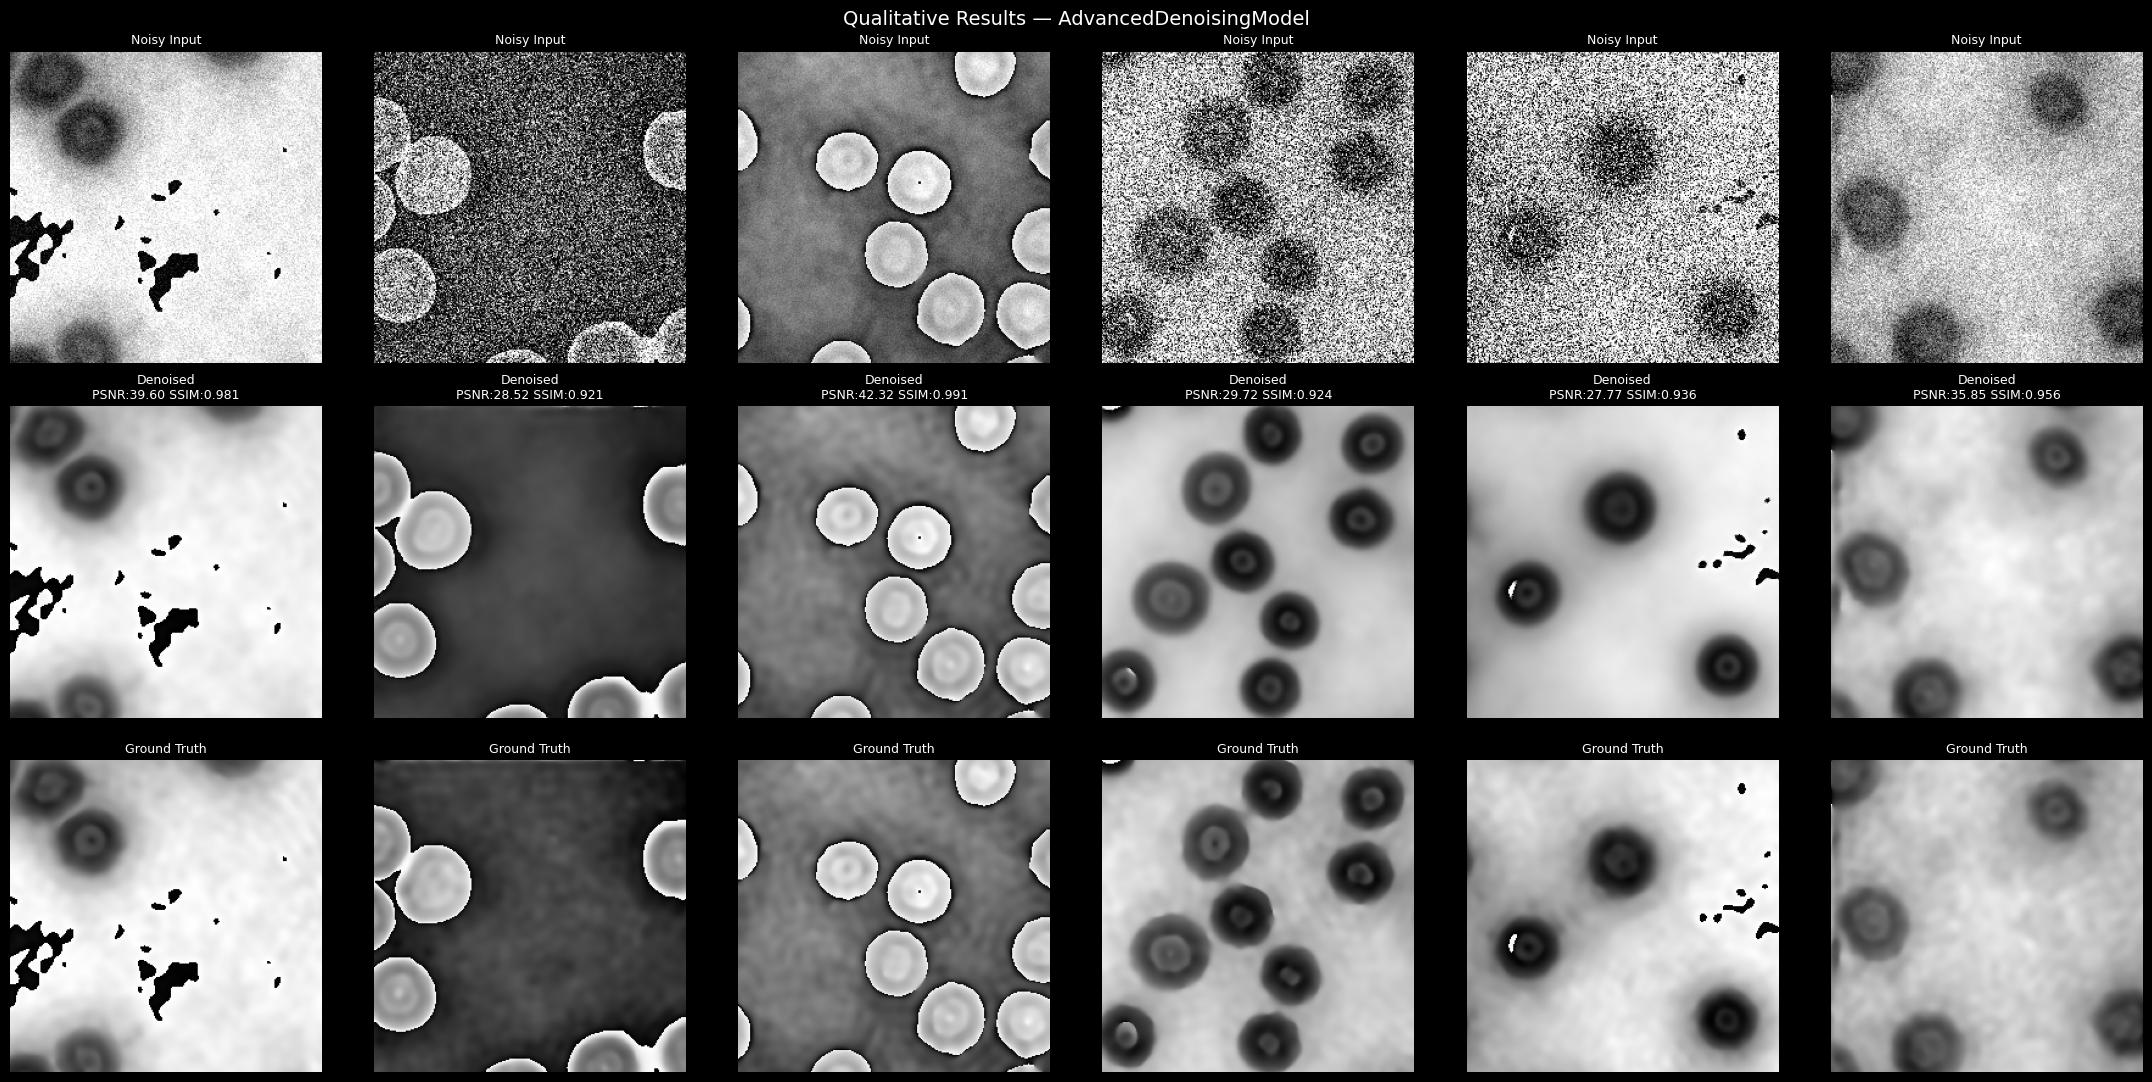

✅ Predictions saved!


In [42]:
model.eval()
imgs, masks = next(iter(test_loader))
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    preds = model(imgs).clamp(0,1)

# Per-image PSNR/SSIM
fig, axes = plt.subplots(3, 6, figsize=(22, 11))

for i in range(6):
    p = psnr_m(preds[i:i+1], masks[i:i+1]).item()
    s = ssim_m(preds[i:i+1], masks[i:i+1]).item()

    axes[0,i].imshow(imgs[i,0].cpu(),  cmap='gray')
    axes[0,i].set_title(f"Noisy Input", fontsize=9); axes[0,i].axis('off')

    axes[1,i].imshow(preds[i,0].cpu(), cmap='gray')
    axes[1,i].set_title(f"Denoised\nPSNR:{p:.2f} SSIM:{s:.3f}", fontsize=9)
    axes[1,i].axis('off')

    axes[2,i].imshow(masks[i,0].cpu(), cmap='gray')
    axes[2,i].set_title(f"Ground Truth", fontsize=9); axes[2,i].axis('off')

plt.suptitle("Qualitative Results — AdvancedDenoisingModel", fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_OUT_DIR/"predictions.png", dpi=200, bbox_inches='tight')
plt.show()
print("✅ Predictions saved!")


SNR  -5 dB → PSNR: 21.72 dB  SSIM: 0.8623
SNR  +0 dB → PSNR: 25.62 dB  SSIM: 0.9068
SNR  +5 dB → PSNR: 30.01 dB  SSIM: 0.9339
SNR +10 dB → PSNR: 33.92 dB  SSIM: 0.9530
SNR +15 dB → PSNR: 37.04 dB  SSIM: 0.9709
SNR +20 dB → PSNR: 40.24 dB  SSIM: 0.9843
SNR +25 dB → PSNR: 43.24 dB  SSIM: 0.9918


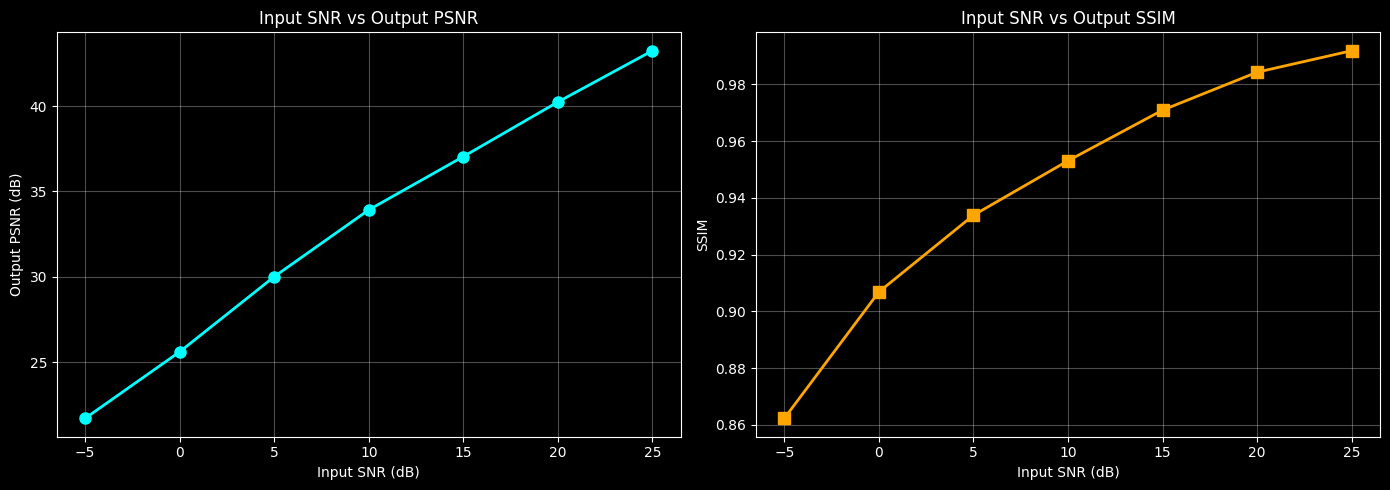

✅ SNR analysis saved!


In [43]:
# Test at each SNR level separately — required for paper
snr_levels = [-5, 0, 5, 10, 15, 20, 25]
snr_results = {}

model.eval()
for snr in snr_levels:
    # Create fixed SNR test set
    snr_ds = PhaseDenoiseDataset(test_p, (HEIGHT,WIDTH), fix_noise=True,
                                  snr_min=snr, snr_max=snr)  # fixed SNR
    snr_loader = DataLoader(snr_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    psnr_m.reset(); ssim_m.reset(); mse_t=0
    with torch.no_grad():
        for imgs, masks in snr_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs).clamp(0,1)
            mse_t  += F.mse_loss(out, masks).item()
            psnr_m.update(out, masks)
            ssim_m.update(out, masks)

    snr_results[snr] = {
        "MSE"  : mse_t/len(snr_loader),
        "PSNR" : psnr_m.compute().item(),
        "SSIM" : ssim_m.compute().item()
    }
    print(f"SNR {snr:+3d} dB → PSNR: {snr_results[snr]['PSNR']:.2f} dB  SSIM: {snr_results[snr]['SSIM']:.4f}")

# Save SNR analysis
with open(MODEL_OUT_DIR/"snr_analysis.json","w") as f:
    json.dump(snr_results, f, indent=2)

# Plot SNR vs PSNR
fig, axes = plt.subplots(1,2,figsize=(14,5))
snrs  = list(snr_results.keys())
psnrs = [snr_results[s]["PSNR"] for s in snrs]
ssims = [snr_results[s]["SSIM"] for s in snrs]

axes[0].plot(snrs, psnrs, 'o-', color="cyan",   linewidth=2, markersize=8)
axes[0].set_title("Input SNR vs Output PSNR"); axes[0].set_xlabel("Input SNR (dB)")
axes[0].set_ylabel("Output PSNR (dB)"); axes[0].grid(alpha=0.3)

axes[1].plot(snrs, ssims, 's-', color="orange", linewidth=2, markersize=8)
axes[1].set_title("Input SNR vs Output SSIM"); axes[1].set_xlabel("Input SNR (dB)")
axes[1].set_ylabel("SSIM"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_OUT_DIR/"snr_analysis.png", dpi=200, bbox_inches='tight')
plt.show()
print("✅ SNR analysis saved!")


In [ ]:
# ── RECREATE testloader ─────────────────────────────────────
import random
from pathlib import Path
from torch.utils.data import DataLoader

best_path = MODEL_OUT_DIR / "best_model.pth"
if not best_path.exists():
    raise FileNotFoundError(f"Missing checkpoint: {best_path}")

# Load the checkpoint to get the saved epoch info
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best model from epoch {ckpt['epoch']}")

# Recreate the same split using the SAME SEED
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

exts = {'.jpg', '.jpeg', '.png'}
all_images = [
    *sorted(f for f in TRAIN_DIR.iterdir() if f.suffix.lower() in exts),
    *sorted(f for f in VAL_DIR.iterdir() if f.suffix.lower() in exts),
]

random.shuffle(all_images)
n = len(all_images)

if n == 0:
    raise ValueError("No images found in Training/Validation. Add images and rerun this cell.")

train_p = all_images[:int(0.70 * n)]
val_p   = all_images[int(0.70 * n):int(0.85 * n)]
test_p  = all_images[int(0.85 * n):]

test_ds = PhaseDenoiseDataset(test_p, (HEIGHT, WIDTH), fix_noise=True)
testloader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)

print(f"Test set size : {len(test_p)} images")
print(f"Test batches  : {len(testloader)}")

Loaded best model from epoch 62
Test set size : 5530 images
Test batches  : 173


In [54]:
import torch.nn.functional as F

def psnr(pred, target):
    mse = F.mse_loss(pred, target)
    if mse == 0:
        return torch.tensor(100.0)
    return 20 * torch.log10(1.0 / torch.sqrt(mse))


def ssim(pred, target):
    C1 = 0.01**2
    C2 = 0.03**2

    mu_x = pred.mean()
    mu_y = target.mean()

    sigma_x = pred.var()
    sigma_y = target.var()
    sigma_xy = ((pred - mu_x) * (target - mu_y)).mean()

    return ((2*mu_x*mu_y + C1)*(2*sigma_xy + C2)) / ((mu_x**2 + mu_y**2 + C1)*(sigma_x + sigma_y + C2))

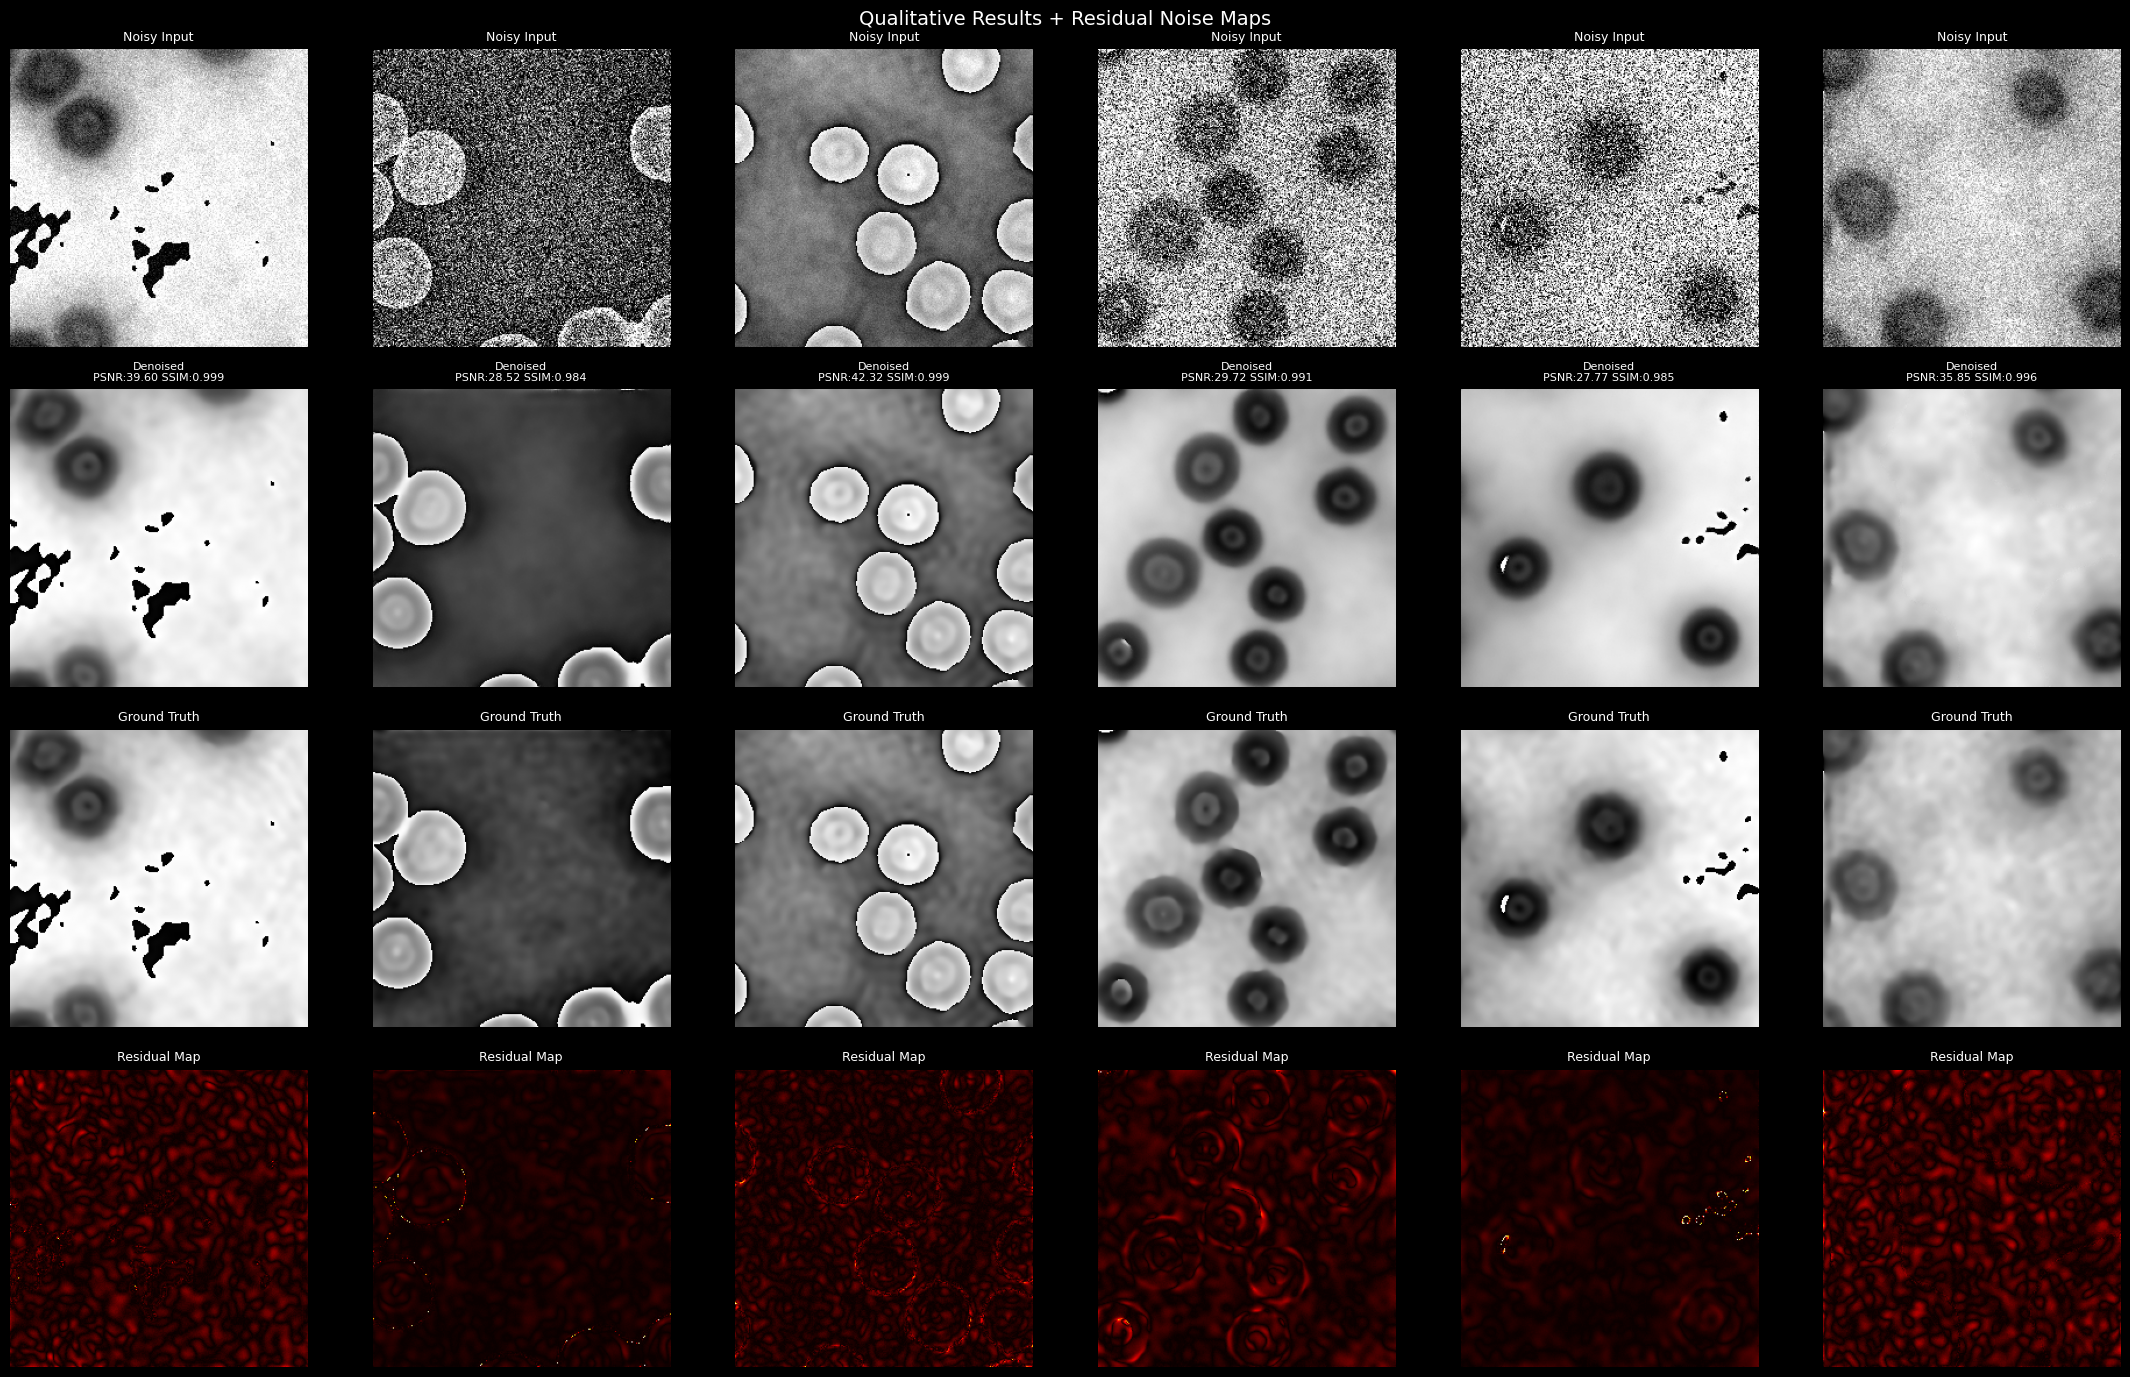

Residual maps saved!


In [55]:
# ── EXTRA ANALYSIS 1: Residual Noise Maps ──────────────────

import matplotlib.pyplot as plt

model.eval()

imgs, masks = next(iter(test_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

with torch.no_grad():
    preds = model(imgs).clamp(0,1)

residuals = (masks - preds).abs()

fig, axes = plt.subplots(4,6, figsize=(22,14))

for i in range(6):

    # Noisy
    axes[0,i].imshow(imgs[i,0].cpu(), cmap='gray')
    axes[0,i].set_title("Noisy Input", fontsize=9)
    axes[0,i].axis('off')

    # Denoised
    axes[1,i].imshow(preds[i,0].cpu(), cmap='gray')

    p = psnr(preds[i:i+1], masks[i:i+1]).item()
    s = ssim(preds[i:i+1], masks[i:i+1]).item()

    axes[1,i].set_title(f"Denoised\nPSNR:{p:.2f} SSIM:{s:.3f}", fontsize=8)
    axes[1,i].axis('off')

    # Ground truth
    axes[2,i].imshow(masks[i,0].cpu(), cmap='gray')
    axes[2,i].set_title("Ground Truth", fontsize=9)
    axes[2,i].axis('off')

    # Residual
    axes[3,i].imshow(residuals[i,0].cpu(), cmap='hot')
    axes[3,i].set_title("Residual Map", fontsize=9)
    axes[3,i].axis('off')

plt.suptitle("Qualitative Results + Residual Noise Maps", fontsize=14)

plt.tight_layout()

plt.savefig(MODEL_OUT_DIR / "residual_maps.png", dpi=200)

plt.show()

print("Residual maps saved!")

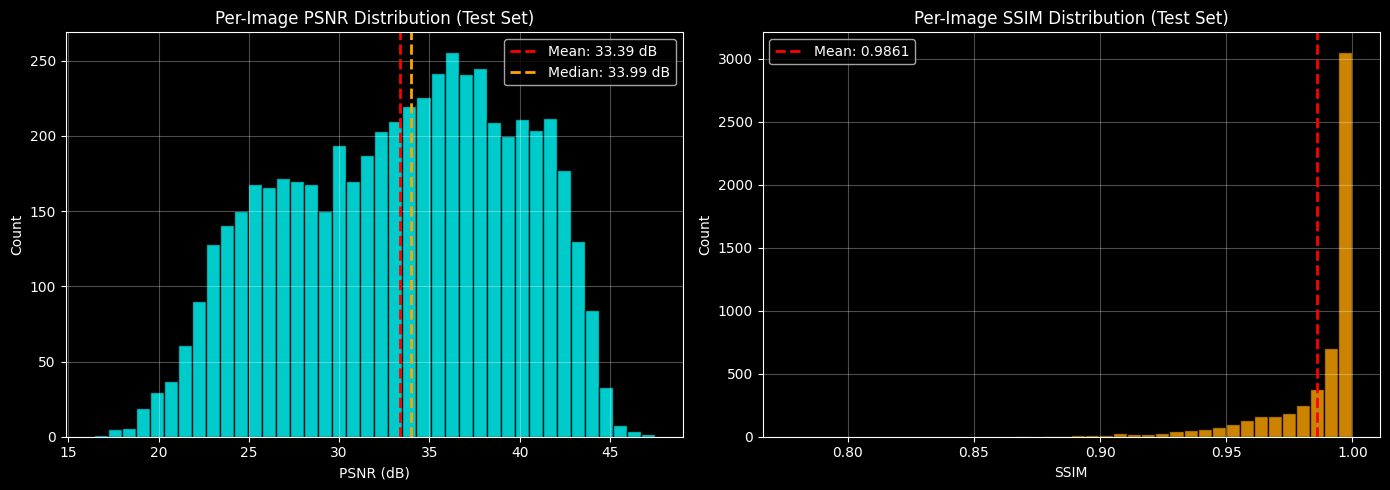

PSNR → Mean: 33.386  Std: 6.344  Min: 16.401  Max: 47.506
SSIM → Mean: 0.9861  Std: 0.0209  Min: 0.7774  Max: 0.9998


In [56]:
 # ── EXTRA ANALYSIS 2: PSNR Distribution on Full Test Set ───
model.eval()
all_psnrs = []
all_ssims = []

with torch.no_grad():
    for imgs, masks in testloader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        out = model(imgs).clamp(0, 1)
        for i in range(out.shape[0]):
            p = psnr(out[i:i+1], masks[i:i+1]).item()
            s = ssim(out[i:i+1], masks[i:i+1]).item()
            all_psnrs.append(p)
            all_ssims.append(s)

import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_psnrs, bins=40, color='cyan', edgecolor='black', alpha=0.8)
axes[0].axvline(np.mean(all_psnrs), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(all_psnrs):.2f} dB')
axes[0].axvline(np.median(all_psnrs), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {np.median(all_psnrs):.2f} dB')
axes[0].set_title('Per-Image PSNR Distribution (Test Set)')
axes[0].set_xlabel('PSNR (dB)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(all_ssims, bins=40, color='orange', edgecolor='black', alpha=0.8)
axes[1].axvline(np.mean(all_ssims), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(all_ssims):.4f}')
axes[1].set_title('Per-Image SSIM Distribution (Test Set)')
axes[1].set_xlabel('SSIM')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_OUT_DIR / "psnr_ssim_distribution.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"PSNR → Mean: {np.mean(all_psnrs):.3f}  Std: {np.std(all_psnrs):.3f}  Min: {min(all_psnrs):.3f}  Max: {max(all_psnrs):.3f}")
print(f"SSIM → Mean: {np.mean(all_ssims):.4f}  Std: {np.std(all_ssims):.4f}  Min: {min(all_ssims):.4f}  Max: {max(all_ssims):.4f}")

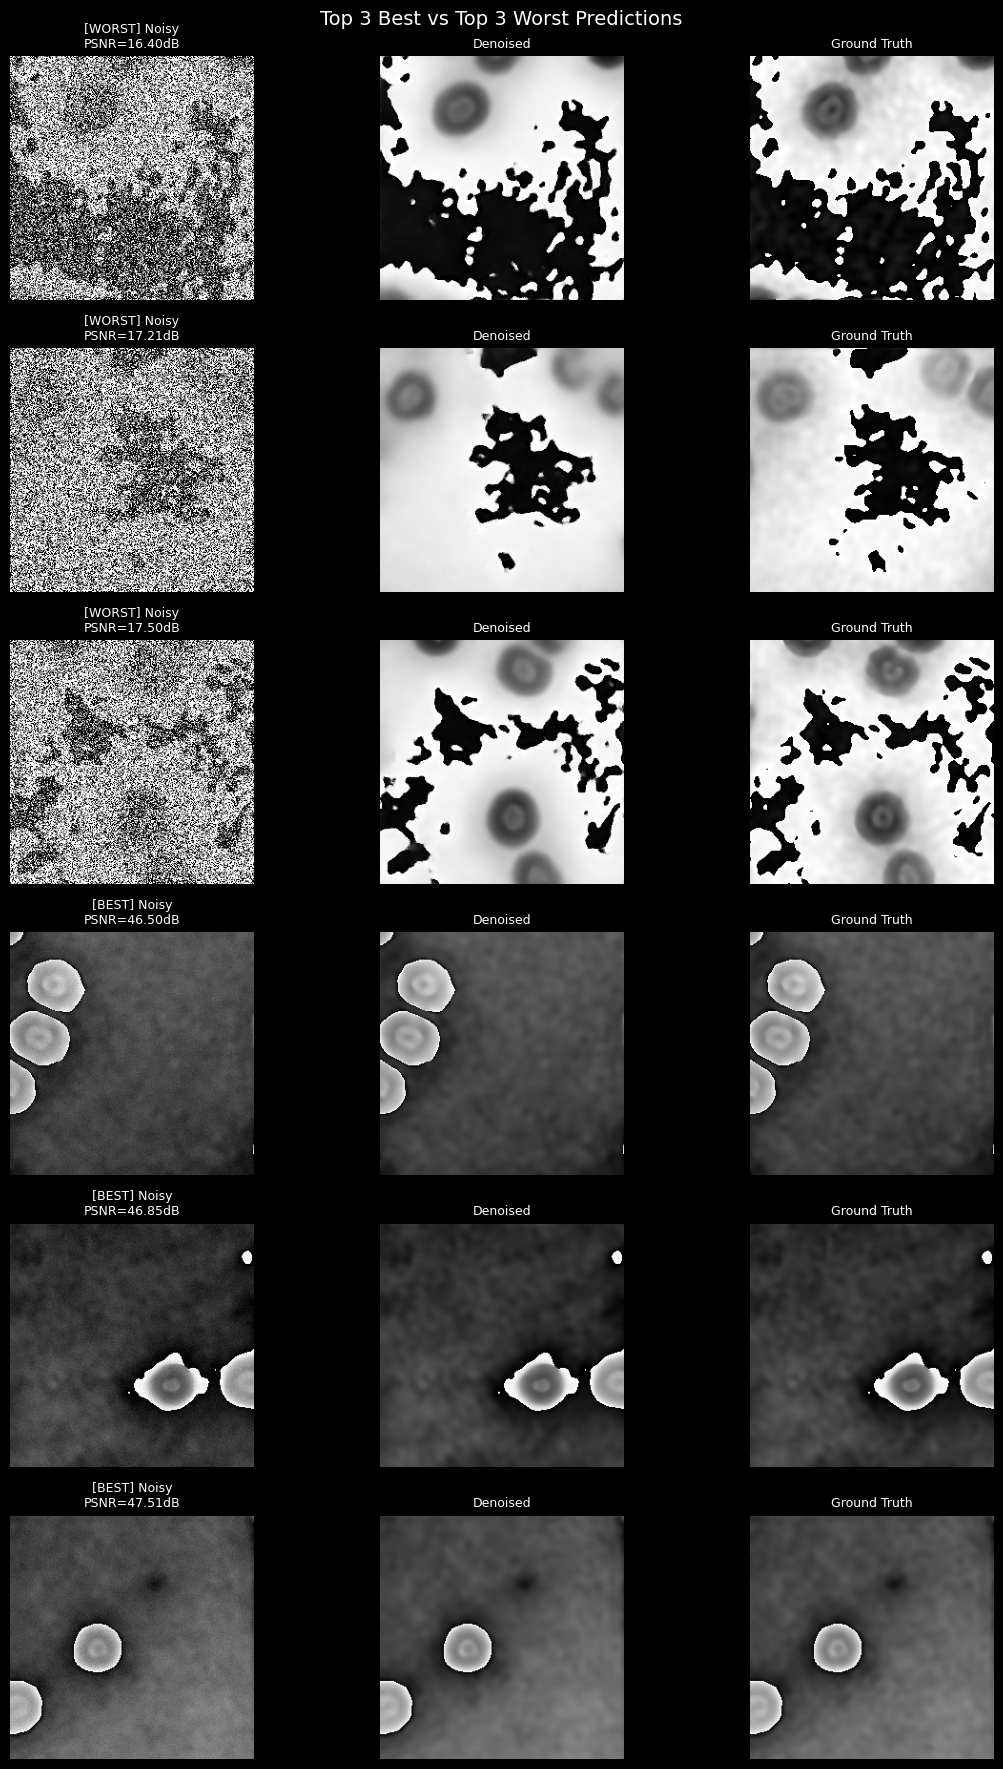

Best/worst predictions saved!


In [59]:
# ── EXTRA ANALYSIS 3: Best vs Worst Samples ────────────────
model.eval()
results = []

with torch.no_grad():
    for batch_idx, (imgs, masks) in enumerate(testloader):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        out = model(imgs).clamp(0, 1)
        for i in range(out.shape[0]):
            p = psnr(out[i:i+1], masks[i:i+1]).item()
            results.append((p, imgs[i].cpu(), out[i].cpu(), masks[i].cpu()))

results.sort(key=lambda x: x[0])
worst3 = results[:3]
best3  = results[-3:]

fig, axes = plt.subplots(6, 3, figsize=(12, 18))
for row, (psnr_val, noisy, pred, clean) in enumerate(worst3):
    axes[row, 0].imshow(noisy[0], cmap='gray')
    axes[row, 0].set_title(f"[WORST] Noisy\nPSNR={psnr_val:.2f}dB", fontsize=9)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(pred[0], cmap='gray')
    axes[row, 1].set_title("Denoised", fontsize=9)
    axes[row, 1].axis('off')
    axes[row, 2].imshow(clean[0], cmap='gray')
    axes[row, 2].set_title("Ground Truth", fontsize=9)
    axes[row, 2].axis('off')

for i, (psnr_val, noisy, pred, clean) in enumerate(best3):
    row = i + 3
    axes[row, 0].imshow(noisy[0], cmap='gray')
    axes[row, 0].set_title(f"[BEST] Noisy\nPSNR={psnr_val:.2f}dB", fontsize=9)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(pred[0], cmap='gray')
    axes[row, 1].set_title("Denoised", fontsize=9)
    axes[row, 1].axis('off')
    axes[row, 2].imshow(clean[0], cmap='gray')
    axes[row, 2].set_title("Ground Truth", fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle("Top 3 Best vs Top 3 Worst Predictions", fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_OUT_DIR / "best_worst_predictions.png", dpi=200, bbox_inches='tight')
plt.show()
print("Best/worst predictions saved!")

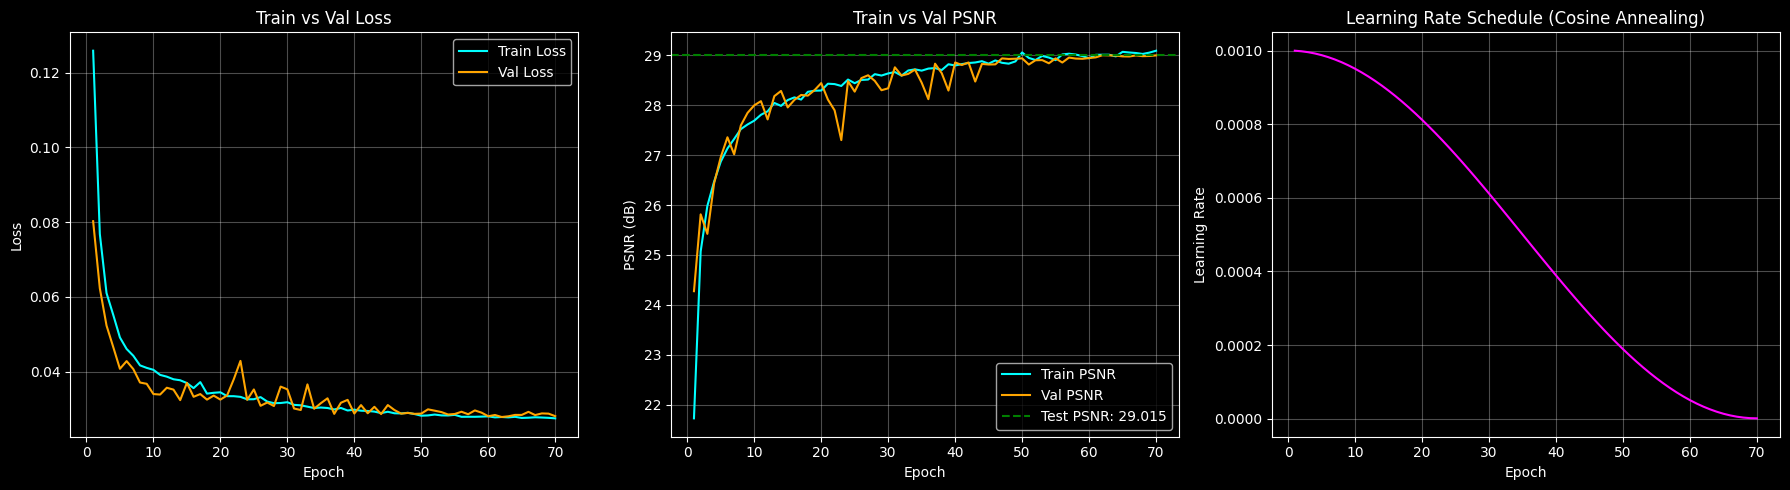

Full training analysis saved!


In [61]:
# ── EXTRA ANALYSIS 4: LR Schedule + Loss Curves ────────────
epochs_range = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='cyan')
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Train vs Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_psnr'], label='Train PSNR', color='cyan')
axes[1].plot(epochs_range, history['val_psnr'], label='Val PSNR', color='orange')
axes[1].axhline(y=29.015, color='green', linestyle='--', label='Test PSNR: 29.015')
axes[1].set_title('Train vs Val PSNR')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PSNR (dB)')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history['lr'], color='magenta')
axes[2].set_title('Learning Rate Schedule (Cosine Annealing)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_OUT_DIR / "full_training_analysis.png", dpi=200, bbox_inches='tight')
plt.show()
print("Full training analysis saved!")